In [ ]:
# Instalação do Apache Spark para Python.
# Fixamos a versão para facilitar a reprodução do trabalho.
%pip install -q "pyspark==4.0.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.2/434.2 MB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Importação das ferramentas utilizadas na configuração.
import os
import sys
import shutil
import subprocess
from pathlib import Path

# Verifica a presença do Java e configura seu caminho.
caminho_java = shutil.which("java")

if caminho_java is None:
    raise RuntimeError(
        "Java não encontrado. Envie esta mensagem para ajustarmos o ambiente."
    )

os.environ["JAVA_HOME"] = str(
    Path(caminho_java).resolve().parent.parent
)

# Garante que o Spark utilize o Python deste notebook.
os.environ["PYSPARK_PYTHON"] = sys.executable

verificacao_java = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=True
)

print("Python:", sys.version.split()[0])
print("Java:")
print(verificacao_java.stderr or verificacao_java.stdout)

# Inicialização do Spark.
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Sistematizacao_Ciencia_de_Dados_II")
    .master("local[2]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Versão do Spark:", spark.version)

# Dados fictícios usados somente para testar o ambiente.
teste = spark.createDataFrame(
    [
        ("A", 10.0),
        ("B", 20.0),
        ("A", 30.0)
    ],
    ["grupo", "valor"]
)

# Registro de uma view e execução de uma consulta Spark SQL.
teste.createOrReplaceTempView("teste_spark")

spark.sql("""
    SELECT
        COUNT(*) AS registros,
        SUM(valor) AS total
    FROM teste_spark
""").show()

print("TESTE CONCLUÍDO: Spark e Spark SQL funcionando.")

Python: 3.13.15
Java:
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)

Versão do Spark: 4.0.1
+---------+-----+
|registros|total|
+---------+-----+
|        3| 60.0|
+---------+-----+

TESTE CONCLUÍDO: Spark e Spark SQL funcionando.


# Sistematização — Ciência de Dados II

## Qualidade do ar: estimativa de PM2.5 e identificação de perfis de poluição com Apache Spark

### 1. Seleção do dataset e definição do problema

Este projeto aplica o processo de KDD a um estudo de caso de consultoria
ambiental, utilizando Apache Spark para preparação, exploração e modelagem
dos dados.

O dataset escolhido é o Beijing Multi-Site Air Quality, disponibilizado
pelo UCI Machine Learning Repository. A escolha considera o volume
superior a 100 mil registros, a documentação da fonte e a possibilidade
de desenvolver análises supervisionadas e não supervisionadas.

Fonte original:
https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data

Referência:
Chen, S. (2017). Beijing Multi-Site Air Quality [Dataset].
UCI Machine Learning Repository.
https://doi.org/10.24432/C5RK5G

### Objetivos

Investigar padrões temporais e espaciais nas medições, comparar modelos
para estimar a concentração de PM2.5 e identificar grupos de observações
com perfis semelhantes de poluição.

### Delimitação

A modelagem supervisionada será uma estimativa contemporânea:
utilizará outras informações disponíveis no horário da observação,
sem utilizar o próprio PM2.5 como variável de entrada.

O estudo é histórico e exploratório. Seus resultados não demonstram
relações de causa e efeito nem constituem um sistema operacional validado.

In [ ]:
# ETAPA 1 — Download e organização dos arquivos originais

from pathlib import Path
from urllib.request import Request, urlopen
import hashlib
import shutil
import zipfile

URL_DATASET = (
    "https://archive.ics.uci.edu/static/public/501/"
    "beijing%2Bmulti%2Bsite%2Bair%2Bquality%2Bdata.zip"
)

PASTA_DADOS = Path("/content/dados_qualidade_ar")
PASTA_ORIGINAIS = PASTA_DADOS / "originais"
ARQUIVO_ZIP = PASTA_DADOS / "fonte_uci.zip"

PASTA_DADOS.mkdir(parents=True, exist_ok=True)
PASTA_ORIGINAIS.mkdir(parents=True, exist_ok=True)

# Reutiliza o download caso o ZIP já esteja disponível e seja válido.
if not ARQUIVO_ZIP.exists() or not zipfile.is_zipfile(ARQUIVO_ZIP):
    print("Baixando o dataset da fonte oficial...")

    requisicao = Request(
        URL_DATASET,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    arquivo_temporario = ARQUIVO_ZIP.with_suffix(".tmp")

    with urlopen(requisicao, timeout=120) as resposta:
        with arquivo_temporario.open("wb") as destino:
            shutil.copyfileobj(resposta, destino)

    if not zipfile.is_zipfile(arquivo_temporario):
        raise RuntimeError(
            "O download não retornou um ZIP válido. Envie esta mensagem."
        )

    arquivo_temporario.replace(ARQUIVO_ZIP)

else:
    print("ZIP já disponível. Reutilizando o arquivo.")


def extrair_zip_seguro(arquivo: Path, destino: Path) -> None:
    """Extrai um ZIP verificando se os caminhos ficam dentro do destino."""
    destino = destino.resolve()
    destino.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(arquivo) as pacote:
        for item in pacote.infolist():
            caminho_final = (destino / item.filename).resolve()

            if not caminho_final.is_relative_to(destino):
                raise RuntimeError(
                    f"Caminho inesperado dentro do ZIP: {item.filename}"
                )

        pacote.extractall(destino)


extrair_zip_seguro(ARQUIVO_ZIP, PASTA_ORIGINAIS)

# A distribuição pode conter outro ZIP dentro do arquivo principal.
for zip_interno in list(PASTA_ORIGINAIS.rglob("*.zip")):
    extrair_zip_seguro(zip_interno, zip_interno.with_suffix(""))

# Seleciona apenas os arquivos originais das estações.
# Outros CSVs eventualmente presentes no pacote não entram na análise.
arquivos_csv = sorted(PASTA_ORIGINAIS.rglob("PRSA_Data_*.csv"))

if len(arquivos_csv) != 12:
    raise RuntimeError(
        f"Foram encontrados {len(arquivos_csv)} arquivos de estações, "
        "mas eram esperados 12. Envie esta saída antes de continuar."
    )

# Identificador do arquivo baixado para apoiar a rastreabilidade.
sha256 = hashlib.sha256(ARQUIVO_ZIP.read_bytes()).hexdigest()

print(f"\nArquivos de estações encontrados: {len(arquivos_csv)}")
print(f"Tamanho do ZIP: {ARQUIVO_ZIP.stat().st_size / 1024**2:.2f} MiB")
print(f"SHA-256 do ZIP: {sha256}")

print("\nArquivos selecionados:")
for arquivo in arquivos_csv:
    print("-", arquivo.name)

print("\nDOWNLOAD E EXTRAÇÃO CONCLUÍDOS.")

Baixando o dataset da fonte oficial...

Arquivos de estações encontrados: 12
Tamanho do ZIP: 7.81 MiB
SHA-256 do ZIP: b04da438b2f331ac0ffd45aebdfec0d20d2367feb5f6948c4b1f7ce1191e33c4

Arquivos selecionados:
- PRSA_Data_Aotizhongxin_20130301-20170228.csv
- PRSA_Data_Changping_20130301-20170228.csv
- PRSA_Data_Dingling_20130301-20170228.csv
- PRSA_Data_Dongsi_20130301-20170228.csv
- PRSA_Data_Guanyuan_20130301-20170228.csv
- PRSA_Data_Gucheng_20130301-20170228.csv
- PRSA_Data_Huairou_20130301-20170228.csv
- PRSA_Data_Nongzhanguan_20130301-20170228.csv
- PRSA_Data_Shunyi_20130301-20170228.csv
- PRSA_Data_Tiantan_20130301-20170228.csv
- PRSA_Data_Wanliu_20130301-20170228.csv
- PRSA_Data_Wanshouxigong_20130301-20170228.csv

DOWNLOAD E EXTRAÇÃO CONCLUÍDOS.


In [ ]:
# ETAPA 2 — Ingestão dos arquivos com Spark DataFrames

from pyspark import StorageLevel
from pyspark.sql import functions as F

# Esquema correspondente à ordem das colunas nos arquivos originais.
esquema_original = """
    No INT,
    year INT,
    month INT,
    day INT,
    hour INT,
    `PM2.5` DOUBLE,
    PM10 DOUBLE,
    SO2 DOUBLE,
    NO2 DOUBLE,
    CO DOUBLE,
    O3 DOUBLE,
    TEMP DOUBLE,
    PRES DOUBLE,
    DEWP DOUBLE,
    RAIN DOUBLE,
    wd STRING,
    WSPM DOUBLE,
    station STRING
"""

df_original = (
    spark.read
    .schema(esquema_original)
    .option("header", True)
    .option("nullValue", "NA")
    .option("mode", "FAILFAST")
    .option("enforceSchema", False)
    .csv([str(arquivo) for arquivo in arquivos_csv])
)

# Padronização dos nomes para facilitar consultas e documentação.
df_bruto = df_original.toDF(
    "numero",
    "ano",
    "mes",
    "dia",
    "hora",
    "pm25",
    "pm10",
    "so2",
    "no2",
    "co",
    "o3",
    "temperatura",
    "pressao",
    "ponto_orvalho",
    "precipitacao",
    "direcao_vento",
    "velocidade_vento",
    "estacao"
)

# Mantém o DataFrame disponível para as próximas verificações.
df_bruto = df_bruto.persist(StorageLevel.MEMORY_AND_DISK)

total_registros = df_bruto.count()
total_estacoes = df_bruto.select("estacao").distinct().count()

if total_registros == 0:
    raise RuntimeError("Nenhum registro foi carregado.")

print("Registros carregados:", f"{total_registros:,}".replace(",", "."))
print("Quantidade de colunas:", len(df_bruto.columns))
print("Estações encontradas:", total_estacoes)

print("\nESTRUTURA DO DATAFRAME:")
df_bruto.printSchema()

print("\nEXEMPLOS DE REGISTROS:")
df_bruto.select(
    "estacao", "ano", "mes", "dia", "hora",
    "pm25", "pm10", "temperatura"
).show(5, truncate=False)

print("\nINGESTÃO COM PYSPARK CONCLUÍDA.")

Registros carregados: 420.768
Quantidade de colunas: 18
Estações encontradas: 12

ESTRUTURA DO DATAFRAME:
root
 |-- numero: integer (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- dia: integer (nullable = true)
 |-- hora: integer (nullable = true)
 |-- pm25: double (nullable = true)
 |-- pm10: double (nullable = true)
 |-- so2: double (nullable = true)
 |-- no2: double (nullable = true)
 |-- co: double (nullable = true)
 |-- o3: double (nullable = true)
 |-- temperatura: double (nullable = true)
 |-- pressao: double (nullable = true)
 |-- ponto_orvalho: double (nullable = true)
 |-- precipitacao: double (nullable = true)
 |-- direcao_vento: string (nullable = true)
 |-- velocidade_vento: double (nullable = true)
 |-- estacao: string (nullable = true)


EXEMPLOS DE REGISTROS:
+-------------+----+---+---+----+----+----+-----------+
|estacao      |ano |mes|dia|hora|pm25|pm10|temperatura|
+-------------+----+---+---+----+----+----+-----------+

In [ ]:
# ETAPA 2 — Diagnóstico inicial de valores ausentes

contagem_ausentes = (
    df_bruto
    .agg(*[
        F.sum(
            F.col(coluna).isNull().cast("long")
        ).alias(coluna)
        for coluna in df_bruto.columns
    ])
    .first()
    .asDict()
)

linhas_diagnostico = []

for coluna in df_bruto.columns:
    quantidade = int(contagem_ausentes[coluna] or 0)
    percentual = round(100.0 * quantidade / total_registros, 2)

    linhas_diagnostico.append(
        (coluna, quantidade, percentual)
    )

diagnostico_ausentes = spark.createDataFrame(
    linhas_diagnostico,
    schema="coluna STRING, ausentes LONG, percentual DOUBLE"
)

print("VALORES AUSENTES POR COLUNA:")

diagnostico_ausentes.orderBy(
    F.desc("ausentes"),
    F.asc("coluna")
).show(len(df_bruto.columns), truncate=False)

VALORES AUSENTES POR COLUNA:
+----------------+--------+----------+
|coluna          |ausentes|percentual|
+----------------+--------+----------+
|co              |20701   |4.92      |
|o3              |13277   |3.16      |
|no2             |12116   |2.88      |
|so2             |9021    |2.14      |
|pm25            |8739    |2.08      |
|pm10            |6449    |1.53      |
|direcao_vento   |1822    |0.43      |
|ponto_orvalho   |403     |0.1       |
|temperatura     |398     |0.09      |
|pressao         |393     |0.09      |
|precipitacao    |390     |0.09      |
|velocidade_vento|318     |0.08      |
|ano             |0       |0.0       |
|dia             |0       |0.0       |
|estacao         |0       |0.0       |
|hora            |0       |0.0       |
|mes             |0       |0.0       |
|numero          |0       |0.0       |
+----------------+--------+----------+



## 2. Pré-processamento e engenharia de atributos

A ingestão com PySpark resultou em 420.768 registros, 18 colunas e
12 estações de monitoramento. No diagnóstico inicial, CO apresentou
a maior proporção de valores ausentes (4,92%), enquanto PM2.5 apresentou
8.739 ausências (2,08%).

Os critérios adotados nesta etapa são:

- Verificar duplicatas e a identificação de cada observação por estação
  e data/hora.
- Retirar da base analítica o número sequencial da linha.
- Converter valores numéricos inválidos em ausências, registrando
  as ocorrências.
- Representar direções do vento ausentes ou inválidas por uma categoria
  explícita.
- Criar atributos temporais, incluindo representações cíclicas de
  hora e mês.
- Diagnosticar valores extremos sem excluí-los automaticamente.
- Preservar as ausências numéricas na base exploratória.
- Na modelagem supervisionada, utilizar apenas registros com PM2.5
  observado e ajustar a imputação dos atributos somente no treinamento.

A base original será preservada em um DataFrame separado.

In [ ]:
# ETAPA 2.1 — Duplicatas, datas e identificação das observações

from pyspark.sql import functions as F
from pyspark import StorageLevel
import math

# Retira o índice da linha e padroniza o nome da estação.
# df_bruto permanece preservado.
df_sem_duplicatas = (
    df_bruto
    .drop("numero")
    .withColumn("estacao", F.trim(F.col("estacao")))
    .dropDuplicates()
)

n_sem_duplicatas = df_sem_duplicatas.count()
n_duplicatas = total_registros - n_sem_duplicatas

# Constrói data/hora sem conversão de fuso.
df_com_data = df_sem_duplicatas.withColumn(
    "data_hora",
    F.try_make_timestamp_ntz(
        "ano", "mes", "dia", "hora",
        F.lit(0), F.lit(0)
    )
)

chave_invalida = (
    F.col("estacao").isNull()
    | (F.col("estacao") == "")
    | F.col("data_hora").isNull()
)

n_chaves_invalidas = df_com_data.filter(chave_invalida).count()

df_validado = df_com_data.filter(~chave_invalida)

# Após retirar repetições idênticas, verifica conflitos:
# mesma estação e horário, mas conteúdo diferente.
conflitos = (
    df_validado
    .groupBy("estacao", "data_hora")
    .count()
    .filter(F.col("count") > 1)
)

n_conflitos = conflitos.count()

print("Duplicatas idênticas removidas:", n_duplicatas)
print("Registros com identificação/data inválida:", n_chaves_invalidas)
print("Chaves com medições conflitantes:", n_conflitos)

if n_conflitos > 0:
    conflitos.show(10, truncate=False)
    raise RuntimeError(
        "Há medições conflitantes. Envie esta saída antes de continuar."
    )

resumo_preprocessamento = {
    "registros_brutos": total_registros,
    "duplicatas_removidas": n_duplicatas,
    "chaves_invalidas_removidas": n_chaves_invalidas,
    "chaves_conflitantes": n_conflitos
}

print("\nVERIFICAÇÃO DE IDENTIFICAÇÃO CONCLUÍDA.")

Duplicatas idênticas removidas: 0
Registros com identificação/data inválida: 0
Chaves com medições conflitantes: 0

VERIFICAÇÃO DE IDENTIFICAÇÃO CONCLUÍDA.


In [ ]:
# ETAPA 2.2 — Validade numérica e direção do vento

colunas_numericas = [
    "pm25", "pm10", "so2", "no2", "co", "o3",
    "temperatura", "pressao", "ponto_orvalho",
    "precipitacao", "velocidade_vento"
]

nao_negativas = {
    "pm25", "pm10", "so2", "no2", "co", "o3",
    "precipitacao", "velocidade_vento"
}

regras_invalidos = {}

for nome in colunas_numericas:
    coluna = F.col(nome)

    # NaN e infinitos não são medições utilizáveis.
    invalido = (
        F.isnan(coluna)
        | coluna.isin(float("inf"), float("-inf"))
    )

    if nome in nao_negativas:
        invalido = invalido | (coluna < 0)

    if nome == "pressao":
        invalido = invalido | (coluna <= 0)

    regras_invalidos[nome] = invalido

# Conta ocorrências antes de fazer as substituições.
contagem_invalidos = (
    df_validado
    .agg(*[
        F.sum(
            F.when(condicao, 1).otherwise(0)
        ).alias(nome)
        for nome, condicao in regras_invalidos.items()
    ])
    .first()
    .asDict()
)

diagnostico_invalidos = spark.createDataFrame(
    [
        (nome, int(contagem_invalidos[nome] or 0))
        for nome in colunas_numericas
    ],
    schema="coluna STRING, invalidos_convertidos_em_nulos LONG"
)

diagnostico_invalidos.show(truncate=False)

# Converte somente os valores inválidos em nulos.
df_tratado = df_validado

for nome, condicao in regras_invalidos.items():
    df_tratado = df_tratado.withColumn(
        nome,
        F.when(condicao, F.lit(None).cast("double"))
        .otherwise(F.col(nome))
    )

# Padroniza a direção do vento.
direcoes_validas = [
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"
]

vento_padronizado = F.upper(F.trim(F.col("direcao_vento")))

df_tratado = df_tratado.withColumn(
    "direcao_vento",
    F.when(
        vento_padronizado.isin(direcoes_validas),
        vento_padronizado
    ).otherwise(F.lit("NAO_INFORMADA"))
)

print("REGRAS DE VALIDADE APLICADAS.")

+----------------+------------------------------+
|coluna          |invalidos_convertidos_em_nulos|
+----------------+------------------------------+
|pm25            |0                             |
|pm10            |0                             |
|so2             |0                             |
|no2             |0                             |
|co              |0                             |
|o3              |0                             |
|temperatura     |0                             |
|pressao         |0                             |
|ponto_orvalho   |0                             |
|precipitacao    |0                             |
|velocidade_vento|0                             |
+----------------+------------------------------+

REGRAS DE VALIDADE APLICADAS.


In [ ]:
df_limpo = (
    df_tratado
    .withColumn("data", F.to_date("data_hora"))
    .withColumn("dia_semana", F.dayofweek("data"))
    # No Spark: domingo = 1 e sábado = 7.
    .withColumn(
        "fim_semana",
        F.when(F.col("dia_semana").isin(1, 7), 1).otherwise(0)
    )
    .withColumn(
        "hora_sin",
        F.sin(2.0 * math.pi * F.col("hora") / 24.0)
    )
    .withColumn(
        "hora_cos",
        F.cos(2.0 * math.pi * F.col("hora") / 24.0)
    )
    .withColumn(
        "mes_sin",
        F.sin(2.0 * math.pi * (F.col("mes") - 1) / 12.0)
    )
    .withColumn(
        "mes_cos",
        F.cos(2.0 * math.pi * (F.col("mes") - 1) / 12.0)
    )
    .persist(StorageLevel.MEMORY_AND_DISK)
)

n_limpo = df_limpo.count()

# Base supervisionada: exige alvo observado.
# Os atributos de entrada ainda podem conter ausências.
df_modelagem = df_limpo.filter(F.col("pm25").isNotNull())
n_modelagem = df_modelagem.count()

# Disponibiliza a base exploratória para a próxima etapa.
df_limpo.createOrReplaceTempView("qualidade_ar")

n_vento_nao_informado = df_limpo.filter(
    F.col("direcao_vento") == "NAO_INFORMADA"
).count()

resumo_preprocessamento.update({
    "registros_base_exploratoria": n_limpo,
    "registros_com_alvo_observado": n_modelagem,
    "registros_sem_alvo_observado": n_limpo - n_modelagem,
    "direcao_vento_nao_informada": n_vento_nao_informado,
    "valores_numericos_invalidos": sum(
        int(valor or 0) for valor in contagem_invalidos.values()
    )
})

print("RESUMO DO PRÉ-PROCESSAMENTO:")
for indicador, valor in resumo_preprocessamento.items():
    print(f"{indicador}: {valor}")

print("\nPERÍODO OBSERVADO:")
df_limpo.agg(
    F.min("data_hora").alias("inicio"),
    F.max("data_hora").alias("fim")
).show(truncate=False)

print("\nBASE EXPLORATÓRIA E BASE SUPERVISIONADA PREPARADAS.")
print("View Spark SQL disponível: qualidade_ar")

RESUMO DO PRÉ-PROCESSAMENTO:
registros_brutos: 420768
duplicatas_removidas: 0
chaves_invalidas_removidas: 0
chaves_conflitantes: 0
registros_base_exploratoria: 420768
registros_com_alvo_observado: 412029
registros_sem_alvo_observado: 8739
direcao_vento_nao_informada: 1822
valores_numericos_invalidos: 0

PERÍODO OBSERVADO:
+-------------------+-------------------+
|inicio             |fim                |
+-------------------+-------------------+
|2013-03-01 00:00:00|2017-02-28 23:00:00|
+-------------------+-------------------+


BASE EXPLORATÓRIA E BASE SUPERVISIONADA PREPARADAS.
View Spark SQL disponível: qualidade_ar


In [ ]:
# ETAPA 2.4 — Diagnóstico descritivo de valores extremos
# Não remove registros nem altera as medições.

quartis = df_limpo.approxQuantile(
    colunas_numericas,
    [0.25, 0.75],
    0.001
)

limites_iqr = {}
expressoes = []

for nome, valores in zip(colunas_numericas, quartis):
    if len(valores) != 2:
        raise RuntimeError(
            f"A coluna {nome} não tem valores suficientes para o diagnóstico."
        )

    q1, q3 = valores
    iqr = q3 - q1
    inferior = q1 - 1.5 * iqr
    superior = q3 + 1.5 * iqr

    limites_iqr[nome] = (q1, q3, inferior, superior)

    fora_limites = (
        (F.col(nome) < inferior)
        | (F.col(nome) > superior)
    )

    expressoes.extend([
        F.count(nome).alias(f"{nome}_observados"),
        F.sum(
            F.when(fora_limites, 1).otherwise(0)
        ).alias(f"{nome}_sinalizados")
    ])

estatisticas_iqr = (
    df_limpo.agg(*expressoes).first().asDict()
)

linhas_outliers = []

for nome, (q1, q3, inferior, superior) in limites_iqr.items():
    observados = int(estatisticas_iqr[f"{nome}_observados"])
    sinalizados = int(
        estatisticas_iqr[f"{nome}_sinalizados"] or 0
    )

    percentual = (
        100.0 * sinalizados / observados
        if observados > 0 else 0.0
    )

    linhas_outliers.append((
        nome,
        round(q1, 2),
        round(q3, 2),
        round(inferior, 2),
        round(superior, 2),
        sinalizados,
        round(percentual, 2)
    ))

diagnostico_outliers = spark.createDataFrame(
    linhas_outliers,
    schema="""
        coluna STRING,
        q1 DOUBLE,
        q3 DOUBLE,
        limite_inferior DOUBLE,
        limite_superior DOUBLE,
        sinalizados LONG,
        percentual DOUBLE
    """
)

diagnostico_outliers.show(
    len(colunas_numericas),
    truncate=False
)

print("Os valores sinalizados foram mantidos.")
print("Os limites acima são descritivos, não filtros de treinamento.")

+----------------+------+------+---------------+---------------+-----------+----------+
|coluna          |q1    |q3    |limite_inferior|limite_superior|sinalizados|percentual|
+----------------+------+------+---------------+---------------+-----------+----------+
|pm25            |20.0  |111.0 |-116.5         |247.5          |19142      |4.65      |
|pm10            |36.0  |145.0 |-127.5         |308.5          |14658      |3.54      |
|so2             |2.86  |19.0  |-21.36         |43.22          |38273      |9.3       |
|no2             |23.0  |71.0  |-49.0          |143.0          |7021       |1.72      |
|co              |500.0 |1500.0|-1000.0        |3000.0         |28054      |7.01      |
|o3              |11.0  |82.0  |-95.5          |188.5          |16599      |4.07      |
|temperatura     |3.1   |23.2  |-27.05         |53.35          |0          |0.0       |
|pressao         |1002.3|1019.0|977.25         |1044.05        |0          |0.0       |
|ponto_orvalho   |-8.9  |15.1  |

### Síntese dos resultados do pré-processamento

A base contém 420.768 registros de 12 estações, abrangendo o período
de 01/03/2013 a 28/02/2017. Não foram encontradas duplicatas idênticas,
identificações ou datas inválidas, nem medições conflitantes para uma
mesma estação e horário.

As verificações de validade numérica também não identificaram ocorrências
segundo as regras adotadas. Esse resultado não demonstra ausência de
todos os possíveis problemas de qualidade: ele se limita às verificações
implementadas.

Todos os 420.768 registros foram preservados na base exploratória.
Para a modelagem supervisionada, foram selecionados 412.029 registros
com PM2.5 observado. Os 8.739 registros sem esse alvo não serão utilizados
no treinamento nem na avaliação supervisionada. As ausências nos
atributos de entrada serão tratadas na etapa de modelagem.

A direção do vento foi padronizada, com 1.822 registros representados
pela categoria NAO_INFORMADA. Também foram criados atributos temporais
de calendário e representações cíclicas da hora e do mês.

O diagnóstico por intervalo interquartil sinalizou 19.142 observações
de PM2.5, equivalentes a 4,65% dos valores observados dessa variável.
Essas observações foram mantidas, pois a sinalização estatística não
comprova erro de medição.

Na precipitação, os quartis estimados Q1 e Q3 foram iguais a zero.
Consequentemente, a regra sinalizou todas as medições positivas:
16.520 registros, correspondentes a 3,93% dos valores observados.
Esse resultado evidencia uma limitação do critério nessa distribuição,
não sendo justificativa para excluir as observações.

Os limites de outliers são descritivos e não serão utilizados como
filtros de treinamento.

## 3. Análise exploratória com Spark SQL

Esta etapa responde a seis perguntas de negócio utilizando consultas
Spark SQL sobre a base preparada. As tabelas agregadas são utilizadas
para produzir visualizações com matplotlib.

### Perguntas de negócio

1. Quais estações apresentam as maiores concentrações médias de PM2.5?
   Objetivo: identificar locais que merecem investigação ambiental
   mais detalhada.

2. Como a concentração de PM2.5 varia entre os meses do ano?
   Objetivo: investigar padrões sazonais úteis ao planejamento
   do monitoramento.

3. Como a concentração de PM2.5 varia ao longo das horas do dia?
   Objetivo: identificar os horários com maiores médias históricas.

4. Como a concentração de PM2.5 se diferencia entre faixas
   de velocidade do vento?
   Objetivo: investigar associações entre as condições meteorológicas
   e as concentrações observadas.

5. Como a concentração média de PM2.5 variou nos anos completos
   de 2014, 2015 e 2016?
   Objetivo: comparar anos sem misturar anos civis completos e parciais.

6. Quais estações apresentam maior proporção de medições ausentes
   de PM2.5 e CO?
   Objetivo: identificar prioridades de investigação da qualidade
   e da disponibilidade dos dados.

### Cuidados de interpretação

As concentrações são analisadas com base nos valores observados,
sem preenchimento das ausências nesta etapa. As contagens e proporções
de disponibilidade acompanham as análises pertinentes.

As comparações são descritivas: não demonstram causalidade,
não representam exposição individual e não constituem previsões.

A análise exploratória descreve o conjunto histórico.
O desempenho dos modelos será avaliado separadamente, na etapa
de modelagem supervisionada.

In [10]:
# ETAPA 3 — Preparação da análise exploratória

from pathlib import Path
import matplotlib.pyplot as plt

# Confere se a preparação anterior continua disponível na sessão.
if "df_limpo" not in globals():
    raise RuntimeError(
        "A base df_limpo não está disponível nesta sessão. "
        "Pare aqui e envie esta mensagem para verificarmos o ambiente."
    )

df_limpo.createOrReplaceTempView("qualidade_ar")

PASTA_RESULTADOS = Path("/content/resultados_cd2")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

resultados_eda = {}


def executar_consulta(nome, consulta):
    """Executa Spark SQL e coleta somente uma pequena tabela agregada."""
    resultado_spark = spark.sql(consulta)

    # Proteção contra a coleta acidental de uma tabela muito grande.
    tabela = resultado_spark.limit(101).toPandas()

    if len(tabela) > 100:
        raise RuntimeError(
            "A consulta retornou mais de 100 linhas. "
            "Revise a agregação antes de coletar os dados."
        )

    if tabela.empty:
        raise RuntimeError(
            f"A consulta {nome} não retornou resultados."
        )

    resultados_eda[nome] = tabela

    print(tabela.to_string(index=False))

    tabela.to_csv(
        PASTA_RESULTADOS / f"{nome}.csv",
        index=False,
        encoding="utf-8"
    )

    return tabela


def finalizar_grafico(nome):
    """Salva e exibe a figura atual."""
    plt.tight_layout()

    plt.savefig(
        PASTA_RESULTADOS / f"{nome}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


print("Ambiente preparado para seis consultas Spark SQL.")
print("Pasta de resultados:", PASTA_RESULTADOS)

Ambiente preparado para seis consultas Spark SQL.
Pasta de resultados: /content/resultados_cd2


      estacao  registros  pm25_observados  cobertura_pct  pm25_medio  pm25_mediano
       Dongsi      35064            34314          97.86       86.19          61.0
Wanshouxigong      35064            34368          98.02       85.02          60.0
 Nongzhanguan      35064            34436          98.21       84.84          59.0
      Gucheng      35064            34418          98.16       83.85          60.0
       Wanliu      35064            34682          98.91       83.37          59.0
     Guanyuan      35064            34448          98.24       82.93          59.0
 Aotizhongxin      35064            34139          97.36       82.77          58.0
      Tiantan      35064            34387          98.07       82.16          59.0
       Shunyi      35064            34151          97.40       79.49          55.0
    Changping      35064            34290          97.79       71.10          46.0
      Huairou      35064            34111          97.28       69.63          46.0
    

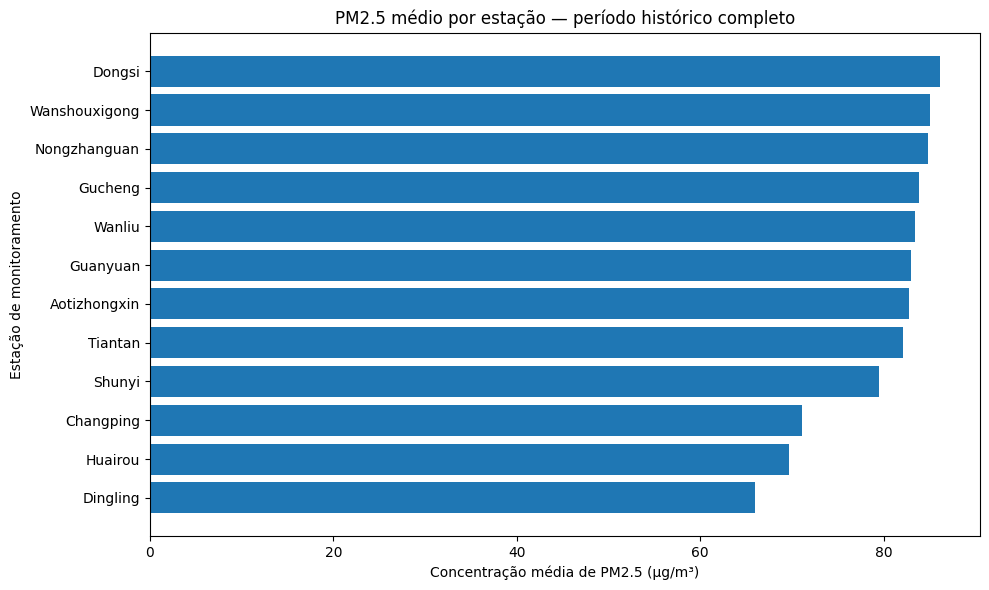


Leitura inicial: Dongsi apresentou a maior média observada (86.19 µg/m³), enquanto Dingling apresentou a menor (65.99 µg/m³).
Uso possível: orientar investigações locais, considerando também a cobertura dos dados e as características de cada estação.


In [11]:
# PERGUNTA 1 — Comparação entre estações

p1 = executar_consulta(
    "p1_estacoes",
    """
    SELECT
        estacao,
        COUNT(*) AS registros,
        COUNT(pm25) AS pm25_observados,
        ROUND(
            100.0 * COUNT(pm25) / CAST(COUNT(*) AS DOUBLE),
            2
        ) AS cobertura_pct,
        ROUND(AVG(pm25), 2) AS pm25_medio,
        ROUND(
            PERCENTILE_APPROX(pm25, 0.5, 10000),
            2
        ) AS pm25_mediano
    FROM qualidade_ar
    GROUP BY estacao
    ORDER BY AVG(pm25) DESC, estacao
    """
)

plt.figure(figsize=(10, 6))
plt.barh(p1["estacao"], p1["pm25_medio"])
plt.gca().invert_yaxis()
plt.xlabel("Concentração média de PM2.5 (µg/m³)")
plt.ylabel("Estação de monitoramento")
plt.title("PM2.5 médio por estação — período histórico completo")
finalizar_grafico("p1_estacoes")

maior = p1.iloc[0]
menor = p1.iloc[-1]

print(
    f"\nLeitura inicial: {maior['estacao']} apresentou a maior "
    f"média observada ({maior['pm25_medio']:.2f} µg/m³), "
    f"enquanto {menor['estacao']} apresentou a menor "
    f"({menor['pm25_medio']:.2f} µg/m³)."
)

print(
    "Uso possível: orientar investigações locais, considerando também "
    "a cobertura dos dados e as características de cada estação."
)

 mes  registros  pm25_observados  pm25_medio  pm25_mediano
   1      35712            35300       93.67          62.0
   2      32544            31856       87.57          45.0
   3      35712            35293       94.66          70.0
   4      34560            33700       72.73          61.0
   5      35712            34712       63.11          50.0
   6      34560            33740       69.09          53.0
   7      35712            34716       71.74          59.0
   8      35712            35215       53.47          41.0
   9      34560            33724       61.48          46.0
  10      35712            34839       91.73          57.0
  11      34560            34183       93.33          66.0
  12      35712            34751      104.58          59.0


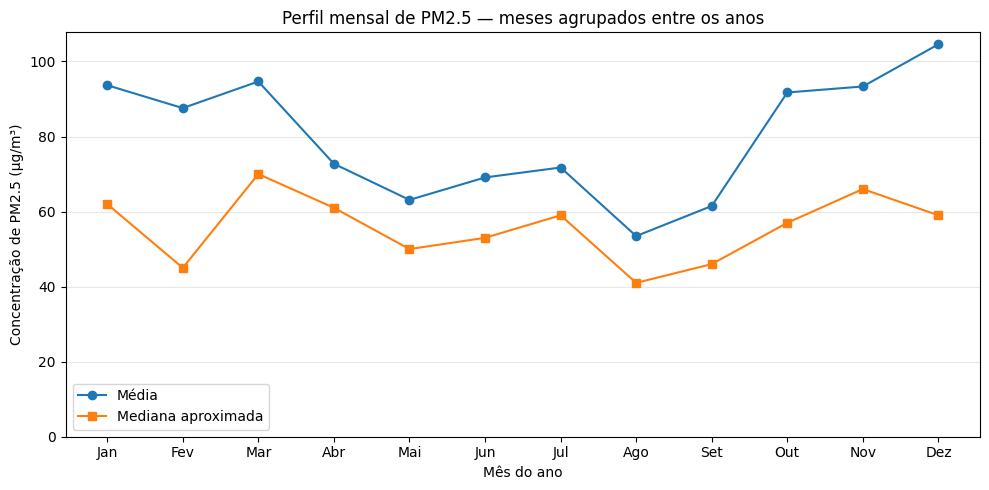


Leitura inicial: a maior média mensal ocorreu em Dez (104.58 µg/m³); a menor ocorreu em Ago (53.47 µg/m³).
Uso possível: planejar investigações e monitoramento considerando os períodos com maiores concentrações históricas. O resultado não prevê o comportamento dos próximos anos.


In [12]:
# PERGUNTA 2 — Perfil mensal histórico

p2 = executar_consulta(
    "p2_meses",
    """
    SELECT
        mes,
        COUNT(*) AS registros,
        COUNT(pm25) AS pm25_observados,
        ROUND(AVG(pm25), 2) AS pm25_medio,
        ROUND(
            PERCENTILE_APPROX(pm25, 0.5, 10000),
            2
        ) AS pm25_mediano
    FROM qualidade_ar
    GROUP BY mes
    ORDER BY mes
    """
)

nomes_meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

plt.figure(figsize=(10, 5))
plt.plot(
    p2["mes"],
    p2["pm25_medio"],
    marker="o",
    label="Média"
)
plt.plot(
    p2["mes"],
    p2["pm25_mediano"],
    marker="s",
    label="Mediana aproximada"
)

plt.xticks(range(1, 13), nomes_meses)
plt.ylim(bottom=0)
plt.xlabel("Mês do ano")
plt.ylabel("Concentração de PM2.5 (µg/m³)")
plt.title("Perfil mensal de PM2.5 — meses agrupados entre os anos")
plt.legend()
plt.grid(axis="y", alpha=0.3)
finalizar_grafico("p2_meses")

maior = p2.loc[p2["pm25_medio"].idxmax()]
menor = p2.loc[p2["pm25_medio"].idxmin()]

print(
    f"\nLeitura inicial: a maior média mensal ocorreu em "
    f"{nomes_meses[int(maior['mes']) - 1]} "
    f"({maior['pm25_medio']:.2f} µg/m³); "
    f"a menor ocorreu em "
    f"{nomes_meses[int(menor['mes']) - 1]} "
    f"({menor['pm25_medio']:.2f} µg/m³)."
)

print(
    "Uso possível: planejar investigações e monitoramento considerando "
    "os períodos com maiores concentrações históricas. "
    "O resultado não prevê o comportamento dos próximos anos."
)

 hora  registros  pm25_observados  pm25_medio
    0      17532            17262       87.59
    1      17532            17252       86.56
    2      17532            17248       84.52
    3      17532            17204       82.01
    4      17532            17233       79.30
    5      17532            17239       76.40
    6      17532            17256       74.24
    7      17532            17231       73.27
    8      17532            17256       74.53
    9      17532            17233       76.06
   10      17532            17162       77.12
   11      17532            16969       77.35
   12      17532            16939       76.86
   13      17532            17031       76.22
   14      17532            17049       75.33
   15      17532            17022       74.52
   16      17532            17055       74.10
   17      17532            17120       75.37
   18      17532            17157       78.02
   19      17532            17200       82.50
   20      17532            17201 

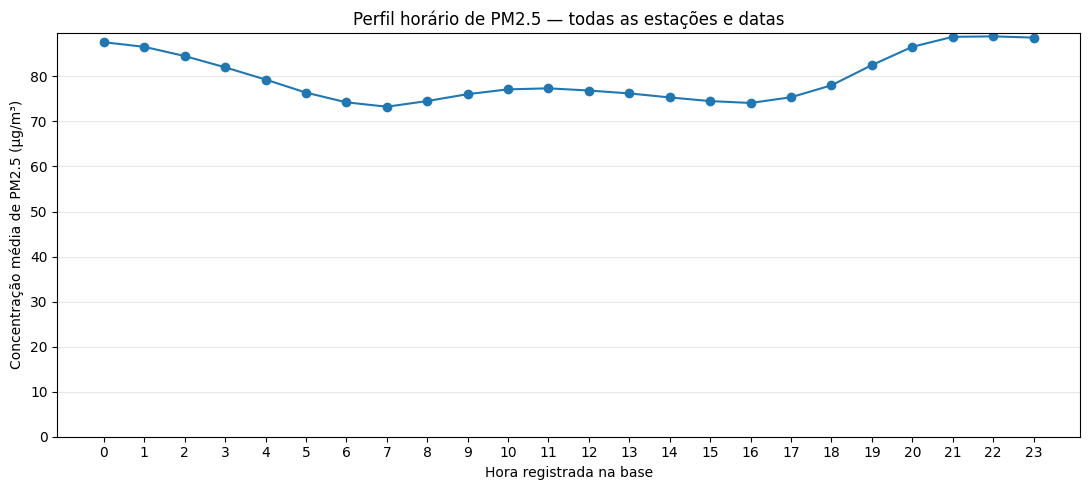


Leitura inicial: a maior média horária ocorreu às 22h (88.89 µg/m³); a menor ocorreu às 07h (73.27 µg/m³).
Uso possível: identificar horários para investigação mais detalhada. A agregação não demonstra que o mesmo padrão ocorre em todas as estações ou em todos os dias.


In [13]:
# PERGUNTA 3 — Perfil horário histórico

p3 = executar_consulta(
    "p3_horarios",
    """
    SELECT
        hora,
        COUNT(*) AS registros,
        COUNT(pm25) AS pm25_observados,
        ROUND(AVG(pm25), 2) AS pm25_medio
    FROM qualidade_ar
    GROUP BY hora
    ORDER BY hora
    """
)

plt.figure(figsize=(11, 5))
plt.plot(p3["hora"], p3["pm25_medio"], marker="o")
plt.xticks(range(24))
plt.ylim(bottom=0)
plt.xlabel("Hora registrada na base")
plt.ylabel("Concentração média de PM2.5 (µg/m³)")
plt.title("Perfil horário de PM2.5 — todas as estações e datas")
plt.grid(axis="y", alpha=0.3)
finalizar_grafico("p3_horarios")

maior = p3.loc[p3["pm25_medio"].idxmax()]
menor = p3.loc[p3["pm25_medio"].idxmin()]

print(
    f"\nLeitura inicial: a maior média horária ocorreu às "
    f"{int(maior['hora']):02d}h "
    f"({maior['pm25_medio']:.2f} µg/m³); "
    f"a menor ocorreu às {int(menor['hora']):02d}h "
    f"({menor['pm25_medio']:.2f} µg/m³)."
)

print(
    "Uso possível: identificar horários para investigação mais detalhada. "
    "A agregação não demonstra que o mesmo padrão ocorre "
    "em todas as estações ou em todos os dias."
)

         faixa_vento  pares_observados  pm25_medio  pm25_mediano
      1: abaixo de 1            111186      102.30          77.0
2: de 1 a menos de 3            243072       79.81          57.0
        3: 3 ou mais             57454       36.16          16.0


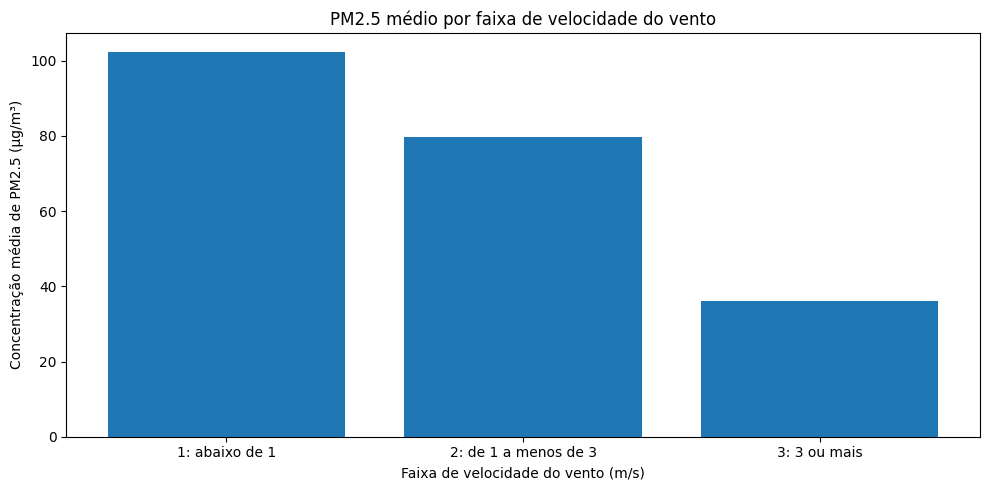


Leitura inicial: a faixa '3: 3 ou mais' m/s apresentou a menor média observada de PM2.5 (36.16 µg/m³).
Uso possível: investigar a associação com condições meteorológicas. Esta comparação não isola os efeitos de estação, época do ano ou outras variáveis; portanto, não demonstra causalidade.


In [14]:
# PERGUNTA 4 — PM2.5 e faixas de velocidade do vento

p4 = executar_consulta(
    "p4_vento",
    """
    WITH dados_com_faixas AS (
        SELECT
            pm25,
            CASE
                WHEN velocidade_vento < 1
                    THEN '1: abaixo de 1'
                WHEN velocidade_vento < 3
                    THEN '2: de 1 a menos de 3'
                ELSE '3: 3 ou mais'
            END AS faixa_vento
        FROM qualidade_ar
        WHERE
            velocidade_vento IS NOT NULL
            AND pm25 IS NOT NULL
    )
    SELECT
        faixa_vento,
        COUNT(*) AS pares_observados,
        ROUND(AVG(pm25), 2) AS pm25_medio,
        ROUND(
            PERCENTILE_APPROX(pm25, 0.5, 10000),
            2
        ) AS pm25_mediano
    FROM dados_com_faixas
    GROUP BY faixa_vento
    ORDER BY faixa_vento
    """
)

plt.figure(figsize=(10, 5))
plt.bar(p4["faixa_vento"], p4["pm25_medio"])
plt.xlabel("Faixa de velocidade do vento (m/s)")
plt.ylabel("Concentração média de PM2.5 (µg/m³)")
plt.title("PM2.5 médio por faixa de velocidade do vento")
finalizar_grafico("p4_vento")

menor = p4.loc[p4["pm25_medio"].idxmin()]

print(
    f"\nLeitura inicial: a faixa '{menor['faixa_vento']}' m/s "
    f"apresentou a menor média observada de PM2.5 "
    f"({menor['pm25_medio']:.2f} µg/m³)."
)

print(
    "Uso possível: investigar a associação com condições meteorológicas. "
    "Esta comparação não isola os efeitos de estação, época do ano "
    "ou outras variáveis; portanto, não demonstra causalidade."
)

 ano  meses_presentes  registros  pm25_observados  cobertura_pct  pm25_medio
2014               12     105120           102260          97.28       85.58
2015               12     105120           102993          97.98       79.63
2016               12     105408           103151          97.86       71.93


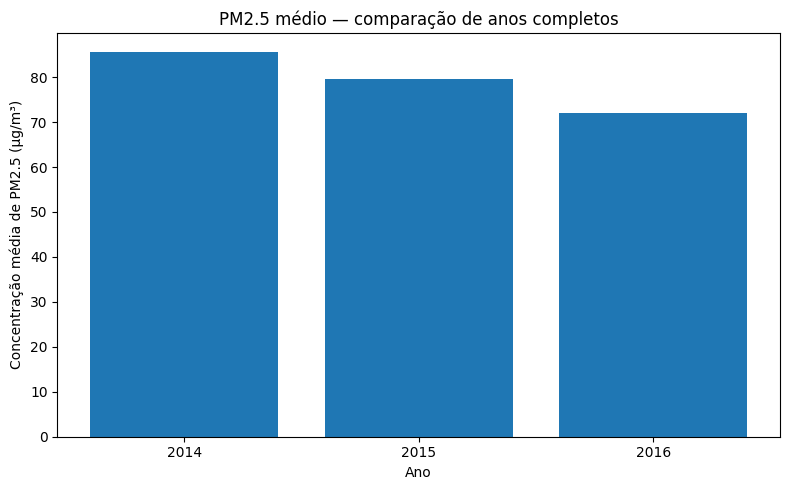


Leitura inicial: a média foi de 85.58 µg/m³ em 2014 e de 71.93 µg/m³ em 2016. A diferença entre o último e o primeiro ano foi -13.65 µg/m³.
Uso possível: acompanhar diferenças históricas entre anos. A comparação não identifica suas causas nem comprova uma tendência que continuará no futuro.


In [15]:
# PERGUNTA 5 — Comparação entre anos civis completos

p5 = executar_consulta(
    "p5_anos",
    """
    SELECT
        ano,
        COUNT(DISTINCT mes) AS meses_presentes,
        COUNT(*) AS registros,
        COUNT(pm25) AS pm25_observados,
        ROUND(
            100.0 * COUNT(pm25) / CAST(COUNT(*) AS DOUBLE),
            2
        ) AS cobertura_pct,
        ROUND(AVG(pm25), 2) AS pm25_medio
    FROM qualidade_ar
    WHERE ano BETWEEN 2014 AND 2016
    GROUP BY ano
    ORDER BY ano
    """
)

plt.figure(figsize=(8, 5))
plt.bar(
    p5["ano"].astype(int).astype(str),
    p5["pm25_medio"]
)
plt.xlabel("Ano")
plt.ylabel("Concentração média de PM2.5 (µg/m³)")
plt.title("PM2.5 médio — comparação de anos completos")
finalizar_grafico("p5_anos")

inicial = p5.iloc[0]
final = p5.iloc[-1]

diferenca = final["pm25_medio"] - inicial["pm25_medio"]

print(
    f"\nLeitura inicial: a média foi de "
    f"{inicial['pm25_medio']:.2f} µg/m³ em "
    f"{int(inicial['ano'])} e de "
    f"{final['pm25_medio']:.2f} µg/m³ em "
    f"{int(final['ano'])}. "
    f"A diferença entre o último e o primeiro ano foi "
    f"{diferenca:+.2f} µg/m³."
)

print(
    "Uso possível: acompanhar diferenças históricas entre anos. "
    "A comparação não identifica suas causas nem comprova "
    "uma tendência que continuará no futuro."
)

      estacao  registros  ausentes_pm25  pm25_ausente_pct  ausentes_co  co_ausente_pct
      Huairou      35064            953              2.72         1422            4.06
 Aotizhongxin      35064            925              2.64         1776            5.07
       Shunyi      35064            913              2.60         2178            6.21
     Dingling      35064            779              2.22         2012            5.74
    Changping      35064            774              2.21         1521            4.34
       Dongsi      35064            750              2.14         3197            9.12
Wanshouxigong      35064            696              1.98         1297            3.70
      Tiantan      35064            677              1.93         1126            3.21
      Gucheng      35064            646              1.84         1401            4.00
 Nongzhanguan      35064            628              1.79         1206            3.44
     Guanyuan      35064            616    

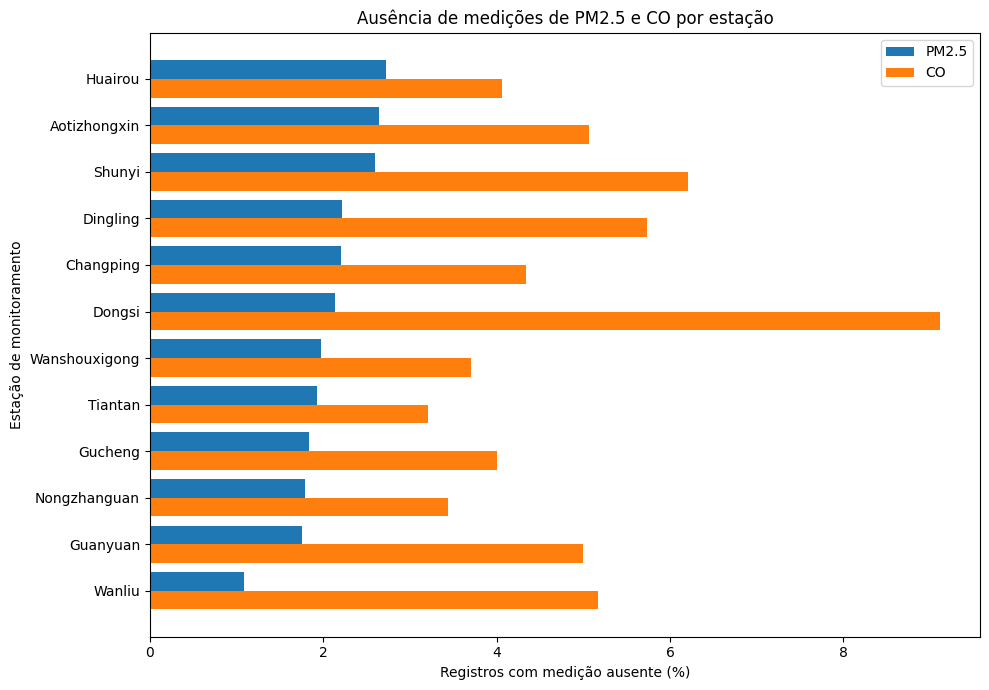


Leitura inicial: Huairou apresentou a maior proporção de ausência de PM2.5 (2.72%). Para CO, a maior proporção ocorreu em Dongsi (9.12%).
Uso possível: priorizar uma auditoria da disponibilidade dos dados. A ausência, isoladamente, não comprova defeito de um sensor.

ETAPA EXPLORATÓRIA EXECUTADA: 6 consultas registradas.


In [16]:
# PERGUNTA 6 — Ausência de medições por estação

p6 = executar_consulta(
    "p6_ausencias",
    """
    SELECT
        estacao,
        COUNT(*) AS registros,
        COUNT(*) - COUNT(pm25) AS ausentes_pm25,
        ROUND(
            100.0 * (COUNT(*) - COUNT(pm25))
            / CAST(COUNT(*) AS DOUBLE),
            2
        ) AS pm25_ausente_pct,
        COUNT(*) - COUNT(co) AS ausentes_co,
        ROUND(
            100.0 * (COUNT(*) - COUNT(co))
            / CAST(COUNT(*) AS DOUBLE),
            2
        ) AS co_ausente_pct
    FROM qualidade_ar
    GROUP BY estacao
    ORDER BY pm25_ausente_pct DESC, estacao
    """
)

posicoes = list(range(len(p6)))

plt.figure(figsize=(10, 7))

plt.barh(
    [p - 0.2 for p in posicoes],
    p6["pm25_ausente_pct"],
    height=0.4,
    label="PM2.5"
)

plt.barh(
    [p + 0.2 for p in posicoes],
    p6["co_ausente_pct"],
    height=0.4,
    label="CO"
)

plt.yticks(posicoes, p6["estacao"])
plt.gca().invert_yaxis()
plt.xlabel("Registros com medição ausente (%)")
plt.ylabel("Estação de monitoramento")
plt.title("Ausência de medições de PM2.5 e CO por estação")
plt.legend()
finalizar_grafico("p6_ausencias")

maior_pm25 = p6.loc[p6["pm25_ausente_pct"].idxmax()]
maior_co = p6.loc[p6["co_ausente_pct"].idxmax()]

print(
    f"\nLeitura inicial: {maior_pm25['estacao']} apresentou "
    f"a maior proporção de ausência de PM2.5 "
    f"({maior_pm25['pm25_ausente_pct']:.2f}%). "
    f"Para CO, a maior proporção ocorreu em "
    f"{maior_co['estacao']} "
    f"({maior_co['co_ausente_pct']:.2f}%)."
)

print(
    "Uso possível: priorizar uma auditoria da disponibilidade dos dados. "
    "A ausência, isoladamente, não comprova defeito de um sensor."
)

print(
    f"\nETAPA EXPLORATÓRIA EXECUTADA: "
    f"{len(resultados_eda)} consultas registradas."
)

### Síntese e interpretação da análise exploratória

As seis consultas Spark SQL identificaram diferenças entre estações,
meses, horários e condições de vento, além de variações na disponibilidade
das medições. Os resultados abaixo foram obtidos nas consultas P1 a P6
deste notebook.

#### Diferenças entre estações

Dongsi apresentou a maior concentração média de PM2.5, com
86,19 µg/m³, enquanto Dingling apresentou a menor, com 65,99 µg/m³.
A diferença foi de 20,20 µg/m³.

Esse resultado pode orientar investigações sobre as características
dos locais monitorados. Entretanto, a comparação é descritiva e não
identifica as causas das diferenças nem representa, necessariamente,
a exposição de toda a população de cada região.

#### Perfil mensal

Dezembro apresentou a maior média histórica de PM2.5, com
104,58 µg/m³, e agosto apresentou a menor, com 53,47 µg/m³.

Em dezembro, a mediana aproximada foi de 59,00 µg/m³, bastante
inferior à média. Isso reforça a importância de apresentar as duas
medidas: a média isolada não resume completamente a distribuição
das concentrações.

Os padrões mensais podem orientar o planejamento de investigações
e do monitoramento. Como os resultados combinam meses de diferentes
anos, não constituem uma previsão para um ano futuro.

#### Perfil horário

A maior média horária ocorreu às 22h, com 88,89 µg/m³, enquanto
a menor ocorreu às 7h, com 73,27 µg/m³.

Esses resultados indicam horários para análises mais detalhadas.
Não é possível afirmar, com essa agregação, que todas as estações
e todos os dias seguem o mesmo comportamento.

#### Associação com a velocidade do vento

A concentração média de PM2.5 foi de 102,30 µg/m³ nas observações
com velocidade do vento inferior a 1 m/s; 79,81 µg/m³ entre 1 e
menos de 3 m/s; e 36,16 µg/m³ com velocidade de 3 m/s ou mais.

Nas faixas analisadas, maiores velocidades do vento estiveram
associadas a menores concentrações médias. A comparação não controla
outras variáveis, como local e época do ano, e não demonstra
causalidade. As faixas foram definidas para esta análise, não como
uma classificação meteorológica oficial.

#### Comparação entre anos completos

As médias de PM2.5 foram de 85,58 µg/m³ em 2014, 79,63 µg/m³
em 2015 e 71,93 µg/m³ em 2016.

Entre 2014 e 2016, houve uma redução de 13,65 µg/m³ na média
observada. Os resultados descrevem uma diminuição nesses três
anos, mas não identificam suas causas nem permitem afirmar que
o comportamento continuará no futuro.

Os anos de 2013 e 2017 foram excluídos dessa comparação porque
estão parcialmente representados na base.

#### Disponibilidade e qualidade dos dados

Huairou apresentou a maior proporção de medições ausentes de
PM2.5, com 2,72%. Para CO, Dongsi apresentou a maior proporção,
com 9,12%.

Essas diferenças podem orientar uma auditoria da coleta e do
registro das medições. Entretanto, a ausência de dados não comprova,
por si só, defeito nos sensores.

#### Recomendações e limitações

Para a consultoria, os resultados sustentam três linhas de ação:
investigar os locais e períodos com maiores médias históricas,
aprofundar a análise das associações meteorológicas e auditar
as estações com maior indisponibilidade de dados.

As médias foram calculadas apenas com as medições observadas.
Se as ausências estiverem relacionadas às condições de poluição,
as comparações poderão sofrer distorções. Além disso, as agregações
podem ocultar diferenças entre estações, anos e episódios específicos.

As análises não estabelecem limites de segurança, não demonstram
relações causais e não substituem a avaliação dos modelos, que será
realizada na etapa supervisionada.

## 4. Modelagem preditiva

### Problema e variável-alvo

O objetivo é estimar a concentração de PM2.5 a partir das demais
medições ambientais e de atributos temporais e categóricos.
Trata-se de regressão supervisionada com estimativa contemporânea,
não de previsão da concentração em um horário futuro.

As entradas incluem outros poluentes, condições meteorológicas,
representações temporais, estação de monitoramento e direção do vento.
O próprio PM2.5 não será utilizado como atributo de entrada.

A aplicação pressupõe a disponibilidade das medições auxiliares
no momento da estimativa. Ausências nessas entradas serão tratadas
pelo procedimento de imputação aprendido no treinamento.

### Divisão temporal

- Treinamento: março de 2013 a fevereiro de 2015.
- Validação: março de 2015 a fevereiro de 2016.
- Teste: março de 2016 a fevereiro de 2017.

Todas as estações seguem os mesmos cortes temporais.
Serão utilizados os registros com PM2.5 observado.

O conjunto de teste não será usado para ajustar o pré-processamento,
treinar os modelos ou escolher o candidato vencedor.
A exploração descritiva anterior contemplou toda a base; portanto,
este procedimento não equivale a uma validação externa com dados
nunca examinados.

### Preparação dos atributos

As ausências numéricas serão preenchidas pelas medianas calculadas
somente no treinamento. As categorias serão codificadas e os atributos
reunidos em um vetor utilizando componentes do Spark ML.

### Modelos e critérios de comparação

Serão comparados Regressão Linear com regularização L2 e Random Forest.
Uma referência simples estimará sempre a média de PM2.5 do treinamento.

A métrica principal será o RMSE na validação, com MAE como critério
de desempate. Também será apresentado o R².

Os parâmetros serão definidos antes da comparação. Não será realizada
uma busca exaustiva de hiperparâmetros, considerando o orçamento
computacional do projeto.

O teste será avaliado somente após a seleção do candidato.

In [17]:
# ETAPA 4.1 — Definição dos atributos e divisão temporal

from pathlib import Path
from time import perf_counter
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

from pyspark import StorageLevel
from pyspark.sql import functions as F

if "df_modelagem" not in globals():
    raise RuntimeError(
        "A base df_modelagem não está disponível. "
        "Pare aqui e envie esta mensagem."
    )

PASTA_RESULTADOS = Path("/content/resultados_cd2")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

SEMENTE = 42

# Medições numéricas utilizadas como entradas.
# PM2.5 NÃO aparece nesta lista.
numericas_pred = [
    "pm10", "so2", "no2", "co", "o3",
    "temperatura", "pressao", "ponto_orvalho",
    "precipitacao", "velocidade_vento"
]

temporais_pred = [
    "hora_sin", "hora_cos", "mes_sin", "mes_cos", "fim_semana"
]

categoricas_pred = ["estacao", "direcao_vento"]

base_pred = df_modelagem.select(
    "data", "data_hora", "pm25",
    *numericas_pred,
    *temporais_pred,
    *categoricas_pred
)

corte_validacao = F.lit("2015-03-01").cast("date")
corte_teste = F.lit("2016-03-01").cast("date")

df_treino = base_pred.filter(
    F.col("data") < corte_validacao
)

df_validacao = base_pred.filter(
    (F.col("data") >= corte_validacao)
    & (F.col("data") < corte_teste)
)

df_teste = base_pred.filter(
    F.col("data") >= corte_teste
)

resumos = []
contagens_modelagem = {}

for nome, base in [
    ("Treino", df_treino),
    ("Validacao", df_validacao),
    ("Teste", df_teste)
]:
    resumo = base.agg(
        F.count("*").alias("registros"),
        F.min("data").alias("inicio"),
        F.max("data").alias("fim")
    ).first()

    if resumo["registros"] == 0:
        raise RuntimeError(f"O conjunto {nome} ficou vazio.")

    contagens_modelagem[nome] = resumo["registros"]

    resumos.append({
        "conjunto": nome,
        "registros": resumo["registros"],
        "inicio": str(resumo["inicio"]),
        "fim": str(resumo["fim"])
    })

if sum(contagens_modelagem.values()) != base_pred.count():
    raise RuntimeError(
        "A divisão não preservou todos os registros."
    )

resumo_divisao = pd.DataFrame(resumos)

print(resumo_divisao.to_string(index=False))

resumo_divisao.to_csv(
    PASTA_RESULTADOS / "divisao_temporal.csv",
    index=False
)

print("\nDIVISÃO TEMPORAL CONCLUÍDA.")
print("O teste permanece sem avaliação de modelos.")

 conjunto  registros     inicio        fim
   Treino     205989 2013-03-01 2015-02-28
Validacao     103287 2015-03-01 2016-02-29
    Teste     102753 2016-03-01 2017-02-28

DIVISÃO TEMPORAL CONCLUÍDA.
O teste permanece sem avaliação de modelos.


In [18]:
# ETAPA 4.2 — Pré-processamento ajustado somente no treinamento

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Imputer,
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)

colunas_imputadas = [f"{c}_imp" for c in numericas_pred]

imputador = Imputer(
    strategy="median",
    inputCols=numericas_pred,
    outputCols=colunas_imputadas,
    relativeError=0.001
)

indexadores = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep",
        stringOrderType="alphabetAsc"
    )
    for c in categoricas_pred
]

codificador = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categoricas_pred],
    outputCols=[f"{c}_ohe" for c in categoricas_pred],
    handleInvalid="keep",
    dropLast=True
)

montador = VectorAssembler(
    inputCols=(
        colunas_imputadas
        + temporais_pred
        + [f"{c}_ohe" for c in categoricas_pred]
    ),
    outputCol="features",
    handleInvalid="error"
)

preprocessador = Pipeline(
    stages=[imputador, *indexadores, codificador, montador]
)

print("Ajustando a preparação somente com dados de treinamento...")

preprocessador_ajustado = preprocessador.fit(df_treino)


def preparar_para_modelo(base):
    """Aplica as transformações já aprendidas, sem ajustá-las novamente."""
    return (
        preprocessador_ajustado
        .transform(base)
        .select(
            "data", "data_hora", "estacao", "pm25", "features"
        )
        .repartition(4, "estacao")
        .sortWithinPartitions("data_hora", "estacao")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )


# Libera versões anteriores caso esta célula seja executada novamente.
for nome_objeto in ["treino_ml", "validacao_ml"]:
    if nome_objeto in globals():
        globals()[nome_objeto].unpersist()

treino_ml = preparar_para_modelo(df_treino)
validacao_ml = preparar_para_modelo(df_validacao)

for nome, base in [
    ("Treino", treino_ml),
    ("Validacao", validacao_ml)
]:
    n = base.count()

    if n != contagens_modelagem[nome]:
        raise RuntimeError(
            f"Houve alteração inesperada no tamanho de {nome}."
        )

    print(f"{nome}: {n} registros preparados.")

# Mostra os valores realmente aprendidos para a imputação.
valores_mediana = (
    preprocessador_ajustado.stages[0]
    .surrogateDF
    .first()
    .asDict()
)

medianas_treino = pd.DataFrame([
    {
        "variavel": c,
        "mediana_treino": float(valores_mediana[c])
    }
    for c in numericas_pred
])

print("\nMEDIANAS APRENDIDAS NO TREINO:")
print(medianas_treino.to_string(index=False))

medianas_treino.to_csv(
    PASTA_RESULTADOS / "medianas_treino.csv",
    index=False
)

print(
    "\nQuantidade de atributos após codificação:",
    treino_ml.first()["features"].size
)

print("PREPARAÇÃO CONCLUÍDA.")
print("PM2.5 não faz parte das entradas.")

Ajustando a preparação somente com dados de treinamento...
Treino: 205989 registros preparados.
Validacao: 103287 registros preparados.

MEDIANAS APRENDIDAS NO TREINO:
        variavel  mediana_treino
            pm10            91.0
             so2            11.0
             no2            48.0
              co          1000.0
              o3            42.0
     temperatura            14.3
         pressao          1010.0
   ponto_orvalho             2.6
    precipitacao             0.0
velocidade_vento             1.3

Quantidade de atributos após codificação: 46
PREPARAÇÃO CONCLUÍDA.
PM2.5 não faz parte das entradas.


In [19]:
# ETAPA 4.3 — Regressão Linear regularizada

from pyspark.ml.regression import LinearRegression

params_lr = dict(
    featuresCol="features",
    labelCol="pm25",
    predictionCol="prediction",
    regParam=0.1,
    elasticNetParam=0.0,
    standardization=True,
    maxIter=100,
    solver="auto"
)

print("Treinando Regressão Linear regularizada...")

inicio = perf_counter()

modelo_lr = LinearRegression(
    **params_lr
).fit(treino_ml)

tempo_lr = perf_counter() - inicio

print(
    f"REGRESSÃO LINEAR CONCLUÍDA em "
    f"{tempo_lr:.1f} segundos."
)

Treinando Regressão Linear regularizada...
REGRESSÃO LINEAR CONCLUÍDA em 6.7 segundos.


In [20]:
# ETAPA 4.4 — Random Forest para regressão

from pyspark.ml.regression import RandomForestRegressor

params_rf = dict(
    featuresCol="features",
    labelCol="pm25",
    predictionCol="prediction",
    numTrees=40,
    maxDepth=8,
    maxBins=32,
    minInstancesPerNode=5,
    featureSubsetStrategy="onethird",
    subsamplingRate=0.8,
    bootstrap=True,
    seed=SEMENTE
)

print("Treinando Random Forest.")
print("Aguarde esta célula terminar antes de executar a próxima.")

inicio = perf_counter()

modelo_rf = RandomForestRegressor(
    **params_rf
).fit(treino_ml)

tempo_rf = perf_counter() - inicio

print(
    f"RANDOM FOREST CONCLUÍDA em "
    f"{tempo_rf:.1f} segundos."
)

print("Árvores treinadas:", modelo_rf.getNumTrees)

Treinando Random Forest.
Aguarde esta célula terminar antes de executar a próxima.
RANDOM FOREST CONCLUÍDA em 36.6 segundos.
Árvores treinadas: 40


Avaliando Regressao_Linear em Treino...
Avaliando Random_Forest em Treino...
Avaliando Regressao_Linear em Validacao...
Avaliando Random_Forest em Validacao...

COMPARAÇÃO NO TREINO E NA VALIDAÇÃO:
          modelo  conjunto      n    RMSE     MAE      R2  negativas_pct
Referencia_media    Treino 205989 79.0454 60.1263 -0.0000         0.0000
Regressao_Linear    Treino 205989 32.8675 22.2680  0.8271         7.9456
   Random_Forest    Treino 205989 26.8338 17.8093  0.8848         0.0000
Referencia_media Validacao 103287 82.6044 61.0146 -0.0177         0.0000
Regressao_Linear Validacao 103287 30.6096 19.7523  0.8603         9.4397
   Random_Forest Validacao 103287 29.3306 16.3009  0.8717         0.0000

Candidato selecionado pelo menor RMSE de validação: Random_Forest
RMSE do candidato: 29.3306
RMSE da referência: 82.6044


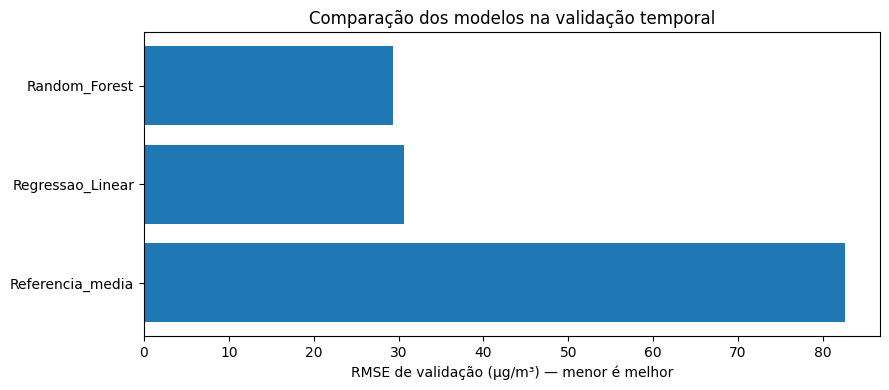


TREINAMENTO E VALIDAÇÃO CONCLUÍDOS.
O teste será avaliado no próximo bloco.


In [21]:
# ETAPA 4.5 — Comparação no treinamento e na validação

from pyspark.ml.evaluation import RegressionEvaluator


def avaliar_regressao(previsoes, nome_modelo, conjunto):
    """Calcula métricas no Spark e verifica a integridade das previsões."""
    dados = (
        previsoes
        .select("pm25", "prediction")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    try:
        invalida = (
            F.col("prediction").isNull()
            | F.isnan("prediction")
            | F.col("prediction").isin(
                float("inf"), float("-inf")
            )
        )

        resumo = dados.agg(
            F.count("*").alias("n"),
            F.sum(
                F.when(invalida, 1).otherwise(0)
            ).alias("invalidas"),
            F.sum(
                F.when(F.col("prediction") < 0, 1).otherwise(0)
            ).alias("negativas")
        ).first()

        if (
            resumo["n"] != contagens_modelagem[conjunto]
            or resumo["invalidas"] > 0
        ):
            raise RuntimeError(
                f"Previsões incompletas ou inválidas: "
                f"{nome_modelo}/{conjunto}."
            )

        resultado = {
            "modelo": nome_modelo,
            "conjunto": conjunto,
            "n": resumo["n"]
        }

        for metrica in ["rmse", "mae", "r2"]:
            valor = RegressionEvaluator(
                labelCol="pm25",
                predictionCol="prediction",
                metricName=metrica
            ).evaluate(dados)

            if not math.isfinite(valor):
                raise RuntimeError(
                    f"Métrica inválida: {nome_modelo}/{metrica}."
                )

            resultado[metrica.upper()] = float(valor)

        # Diagnóstico: não alteramos ou truncamos as previsões.
        resultado["negativas_pct"] = (
            100.0 * resumo["negativas"] / resumo["n"]
        )

        return resultado

    finally:
        dados.unpersist()


# Referência calculada APENAS com o treinamento.
media_alvo_treino = float(
    treino_ml.agg(F.avg("pm25")).first()[0]
)

modelos_ajustados = {
    "Regressao_Linear": modelo_lr,
    "Random_Forest": modelo_rf
}

linhas_metricas = []

for conjunto, base in [
    ("Treino", treino_ml),
    ("Validacao", validacao_ml)
]:
    referencia = base.withColumn(
        "prediction",
        F.lit(media_alvo_treino)
    )

    linhas_metricas.append(
        avaliar_regressao(
            referencia,
            "Referencia_media",
            conjunto
        )
    )

    for nome_modelo, modelo in modelos_ajustados.items():
        print(f"Avaliando {nome_modelo} em {conjunto}...")

        linhas_metricas.append(
            avaliar_regressao(
                modelo.transform(base),
                nome_modelo,
                conjunto
            )
        )

metricas_modelos = pd.DataFrame(linhas_metricas)

print("\nCOMPARAÇÃO NO TREINO E NA VALIDAÇÃO:")
print(metricas_modelos.round(4).to_string(index=False))

metricas_modelos.to_csv(
    PASTA_RESULTADOS / "metricas_treino_validacao.csv",
    index=False
)

# A seleção utiliza SOMENTE a validação.
tabela_validacao = (
    metricas_modelos[
        metricas_modelos["conjunto"] == "Validacao"
    ]
    .sort_values(["RMSE", "MAE", "modelo"])
    .reset_index(drop=True)
)

candidatos = tabela_validacao[
    tabela_validacao["modelo"].isin(modelos_ajustados)
]

nome_escolhido = candidatos.iloc[0]["modelo"]
melhor_modelo = modelos_ajustados[nome_escolhido]

rmse_escolhido = float(candidatos.iloc[0]["RMSE"])

rmse_referencia = float(
    tabela_validacao.loc[
        tabela_validacao["modelo"] == "Referencia_media",
        "RMSE"
    ].iloc[0]
)

print(
    "\nCandidato selecionado pelo menor RMSE de validação:",
    nome_escolhido
)
print(f"RMSE do candidato: {rmse_escolhido:.4f}")
print(f"RMSE da referência: {rmse_referencia:.4f}")

if rmse_escolhido >= rmse_referencia:
    print(
        "ATENÇÃO: o candidato não superou a referência "
        "simples nesta validação."
    )

# Visualização somente da pequena tabela de métricas.
plt.figure(figsize=(9, 4))

plt.barh(
    tabela_validacao["modelo"],
    tabela_validacao["RMSE"]
)

plt.gca().invert_yaxis()
plt.xlabel("RMSE de validação (µg/m³) — menor é melhor")
plt.title("Comparação dos modelos na validação temporal")
plt.tight_layout()

plt.savefig(
    PASTA_RESULTADOS / "comparacao_modelos_validacao.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Registro das decisões e configurações do experimento.
protocolo = {
    "alvo": "pm25",
    "tipo": "estimativa contemporânea",
    "inicio_validacao": "2015-03-01",
    "inicio_teste": "2016-03-01",
    "criterio_selecao": (
        "menor RMSE de validação; desempate por MAE"
    ),
    "modelo_selecionado": nome_escolhido,
    "parametros_lr": params_lr,
    "parametros_rf": params_rf,
    "tempo_ajuste_lr_s": tempo_lr,
    "tempo_ajuste_rf_s": tempo_rf,
    "media_alvo_treino": media_alvo_treino,
    "teste_avaliado": False
}

(PASTA_RESULTADOS / "protocolo_modelagem.json").write_text(
    json.dumps(protocolo, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("\nTREINAMENTO E VALIDAÇÃO CONCLUÍDOS.")
print("O teste será avaliado no próximo bloco.")

### Avaliação final no conjunto de teste

Após a comparação dos modelos no período de validação, a Random Forest
foi selecionada pelo menor RMSE. O conjunto de teste permaneceu isolado
durante o treinamento, o pré-processamento e a seleção do modelo.

Nesta etapa, o modelo selecionado será aplicado uma única vez ao período
de março de 2016 a fevereiro de 2017.

As métricas obtidas no teste serão utilizadas para avaliar a capacidade
de generalização temporal da solução. O resultado do teste não será
utilizado para substituir o modelo escolhido anteriormente.

In [22]:
# ETAPA 4.6 — Preparação final do conjunto de teste

if "melhor_modelo" not in globals():
    raise RuntimeError(
        "O modelo selecionado não está disponível. "
        "Execute primeiro as células anteriores da modelagem."
    )

# O mesmo preprocessador ajustado SOMENTE no treinamento
# é aplicado ao teste.
teste_ml = preparar_para_modelo(df_teste)

n_teste_preparado = teste_ml.count()

print("Registros esperados no teste:", contagens_modelagem["Teste"])
print("Registros preparados:", n_teste_preparado)

if n_teste_preparado != contagens_modelagem["Teste"]:
    raise RuntimeError(
        "O número de registros do teste mudou durante a preparação."
    )

print("\nCONJUNTO DE TESTE PREPARADO.")
print("Nenhum novo ajuste do preprocessador foi realizado.")

Registros esperados no teste: 102753
Registros preparados: 102753

CONJUNTO DE TESTE PREPARADO.
Nenhum novo ajuste do preprocessador foi realizado.


In [23]:
# ETAPA 4.7 — Avaliação única do modelo selecionado no teste

print("Modelo selecionado anteriormente:", nome_escolhido)

previsoes_teste = (
    melhor_modelo
    .transform(teste_ml)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

resultado_teste = avaliar_regressao(
    previsoes_teste,
    nome_escolhido,
    "Teste"
)

metricas_teste = pd.DataFrame([resultado_teste])

print("\nRESULTADO FINAL NO TESTE:")
print(
    metricas_teste
    .round(4)
    .to_string(index=False)
)

metricas_teste.to_csv(
    PASTA_RESULTADOS / "metricas_teste.csv",
    index=False
)

print("\nAVALIAÇÃO FINAL DO TESTE CONCLUÍDA.")

Modelo selecionado anteriormente: Random_Forest

RESULTADO FINAL NO TESTE:
       modelo conjunto      n    RMSE     MAE     R2  negativas_pct
Random_Forest    Teste 102753 26.6613 16.2067 0.8962            0.0

AVALIAÇÃO FINAL DO TESTE CONCLUÍDA.


COMPARAÇÃO FINAL:
 conjunto    RMSE     MAE     R2
Validacao 29.3306 16.3009 0.8717
    Teste 26.6613 16.2067 0.8962

Variação do RMSE entre validação e teste: -9.10%


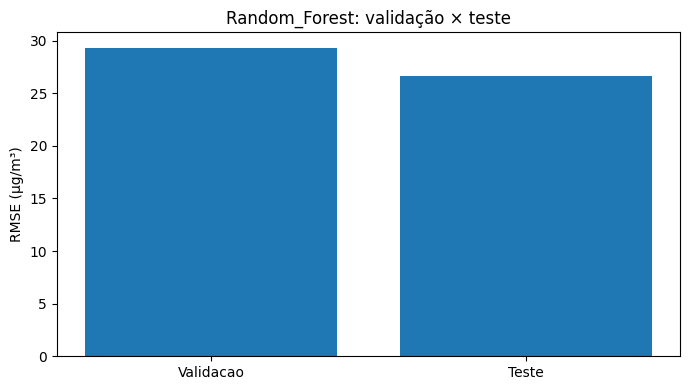

In [24]:
# ETAPA 4.8 — Comparação entre validação e teste

resultado_validacao_escolhido = (
    metricas_modelos[
        (metricas_modelos["modelo"] == nome_escolhido)
        & (metricas_modelos["conjunto"] == "Validacao")
    ]
    .iloc[0]
)

resultado_teste_escolhido = metricas_teste.iloc[0]

comparacao_final = pd.DataFrame([
    {
        "conjunto": "Validacao",
        "RMSE": resultado_validacao_escolhido["RMSE"],
        "MAE": resultado_validacao_escolhido["MAE"],
        "R2": resultado_validacao_escolhido["R2"]
    },
    {
        "conjunto": "Teste",
        "RMSE": resultado_teste_escolhido["RMSE"],
        "MAE": resultado_teste_escolhido["MAE"],
        "R2": resultado_teste_escolhido["R2"]
    }
])

print("COMPARAÇÃO FINAL:")
print(
    comparacao_final
    .round(4)
    .to_string(index=False)
)

variacao_rmse_pct = (
    100.0
    * (
        resultado_teste_escolhido["RMSE"]
        - resultado_validacao_escolhido["RMSE"]
    )
    / resultado_validacao_escolhido["RMSE"]
)

print(
    f"\nVariação do RMSE entre validação e teste: "
    f"{variacao_rmse_pct:+.2f}%"
)

comparacao_final.to_csv(
    PASTA_RESULTADOS / "comparacao_validacao_teste.csv",
    index=False
)

plt.figure(figsize=(7, 4))

plt.bar(
    comparacao_final["conjunto"],
    comparacao_final["RMSE"]
)

plt.ylabel("RMSE (µg/m³)")
plt.title(
    f"{nome_escolhido}: validação × teste"
)

plt.tight_layout()

plt.savefig(
    PASTA_RESULTADOS / "validacao_vs_teste.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [25]:
# ETAPA 4.9 — Exemplos de estimativas do modelo

amostra_previsoes = (
    previsoes_teste
    .select(
        "data_hora",
        "estacao",
        F.round("pm25", 2).alias("pm25_real"),
        F.round("prediction", 2).alias("pm25_estimado"),
        F.round(
            F.abs(F.col("pm25") - F.col("prediction")),
            2
        ).alias("erro_absoluto")
    )
    .orderBy("data_hora", "estacao")
    .limit(15)
)

print("EXEMPLOS DE PREVISÕES:")
amostra_previsoes.show(
    15,
    truncate=False
)

EXEMPLOS DE PREVISÕES:
+-------------------+-------------+---------+-------------+-------------+
|data_hora          |estacao      |pm25_real|pm25_estimado|erro_absoluto|
+-------------------+-------------+---------+-------------+-------------+
|2016-03-01 00:00:00|Aotizhongxin |63.0     |59.7         |3.3          |
|2016-03-01 00:00:00|Changping    |89.0     |95.94        |6.94         |
|2016-03-01 00:00:00|Dingling     |74.0     |64.42        |9.58         |
|2016-03-01 00:00:00|Dongsi       |64.0     |56.25        |7.75         |
|2016-03-01 00:00:00|Guanyuan     |52.0     |48.07        |3.93         |
|2016-03-01 00:00:00|Gucheng      |105.0    |85.7         |19.3         |
|2016-03-01 00:00:00|Huairou      |81.0     |74.04        |6.96         |
|2016-03-01 00:00:00|Nongzhanguan |55.0     |37.11        |17.89        |
|2016-03-01 00:00:00|Shunyi       |92.0     |71.68        |20.32        |
|2016-03-01 00:00:00|Tiantan      |68.0     |63.24        |4.76         |
|2016-03-01 00:

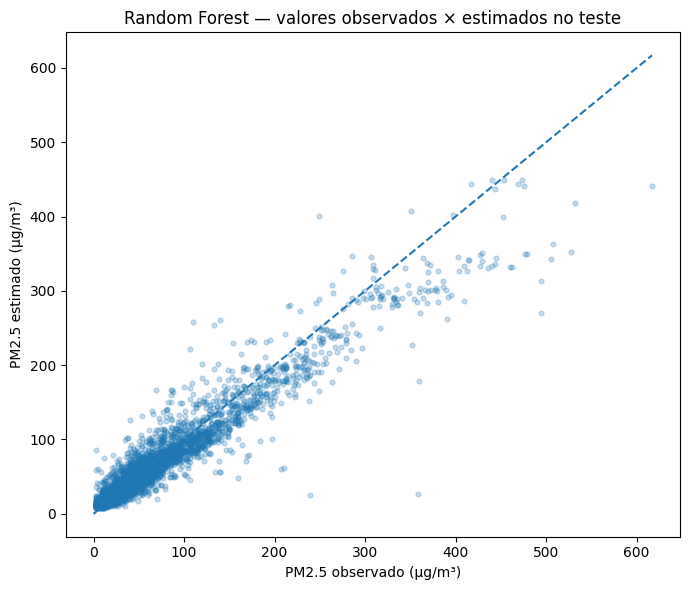

In [26]:
# ETAPA 4.10 — Relação entre valor real e estimado

amostra_grafico = (
    previsoes_teste
    .select(
        F.col("pm25").alias("real"),
        F.col("prediction").alias("estimado")
    )
    .sample(
        withReplacement=False,
        fraction=0.03,
        seed=SEMENTE
    )
    .limit(3000)
    .toPandas()
)

plt.figure(figsize=(7, 6))

plt.scatter(
    amostra_grafico["real"],
    amostra_grafico["estimado"],
    alpha=0.25,
    s=12
)

limite = max(
    amostra_grafico["real"].max(),
    amostra_grafico["estimado"].max()
)

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)

plt.xlabel("PM2.5 observado (µg/m³)")
plt.ylabel("PM2.5 estimado (µg/m³)")
plt.title(
    "Random Forest — valores observados × estimados no teste"
)

plt.tight_layout()

plt.savefig(
    PASTA_RESULTADOS / "real_vs_estimado_teste.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [27]:
# ETAPA 4.11 — Registro final do protocolo

protocolo["teste_avaliado"] = True
protocolo["metricas_teste"] = {
    "RMSE": float(resultado_teste_escolhido["RMSE"]),
    "MAE": float(resultado_teste_escolhido["MAE"]),
    "R2": float(resultado_teste_escolhido["R2"]),
    "negativas_pct": float(
        resultado_teste_escolhido["negativas_pct"]
    )
}

(PASTA_RESULTADOS / "protocolo_modelagem.json").write_text(
    json.dumps(
        protocolo,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

print("PROTOCOLO FINAL DA MODELAGEM SALVO.")

PROTOCOLO FINAL DA MODELAGEM SALVO.
